# BNET SCPI Smoke Tests

This notebook is for first-pass testing of the custom BNET API/SCPI commands on a Red Pitaya at `169.254.77.151`.

It has two goals:

1. Test that the new BNET SCPI commands are visible and basically functional.
2. Prepare the shape of a later end-to-end butterfly-network test where BNET output is sent to output 1 and captured back on input 1.

Assumptions:

- The board is reachable over Ethernet.
- The custom SCPI server has been compiled, installed, and restarted on the Red Pitaya.
- The matching FPGA bitstream with BNET at `sys[7]` has been loaded.
- For the ASG/acquisition loopback section, physically connect `OUT1` to `IN1` with a coax cable.

In [1]:
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt

# redpitaya_scpi.py is in the same folder as this notebook.
import redpitaya_scpi as scpi

RP_IP = "169.254.77.151"
RP_PORT = 5000
TIMEOUT_S = 5.0

print(f"Notebook ready for Red Pitaya at {RP_IP}:{RP_PORT}")

Notebook ready for Red Pitaya at 169.254.77.151:5000


## Connection Helpers

The low-level `redpitaya_scpi.scpi` object already has `tx_txt()` and `txrx_txt()` methods.

The small wrappers below add logging, so each notebook cell shows exactly which SCPI command was sent and what came back. That is useful while the custom server is still being debugged.

In [2]:
rp = scpi.scpi(RP_IP, timeout=TIMEOUT_S, port=RP_PORT)

def cmd(message: str, check: bool = True) -> None:
    """Send a command that does not return a value.

    Example:
        cmd("BNET:RST")

    SCPI commands ending in `?` are queries and should use `query()` instead.
    """
    print(f">> {message}")
    rp.tx_txt(message)
    if check:
        rp.check_error(stop=False)

def query(message: str, check: bool = True) -> str:
    """Send a query command and return the response text.

    Example:
        status = query("BNET:STATUS?")
    """
    print(f">> {message}")
    response = rp.txrx_txt(message)
    print(f"<< {response}")
    if check:
        rp.check_error(stop=False)
    return response

def query_int(message: str) -> int:
    """Query a command expected to return an integer."""
    return int(query(message).strip())

def next_scpi_error() -> str:
    """Read one entry from the SCPI error queue without using rp.check_error()."""
    print(">> SYST:ERR:NEXT?")
    err = rp.txrx_txt("SYST:ERR:NEXT?")
    print(f"<< {err}")
    return err

def assert_no_scpi_error(context: str) -> None:
    """Raise immediately if the previous command placed anything in the SCPI error queue.

    The stock helper prints errors but does not always stop the notebook. For
    DDR streaming tests we want fail-fast behavior, because continuing after a
    failed reserve/upload/attach makes later assertions misleading.
    """
    err = next_scpi_error()
    if not err.startswith("0,"):
        raise RuntimeError(f"{context} failed with SCPI error: {err}")

def strict_cmd(message: str) -> None:
    """Send a command and raise on any SCPI error response."""
    print(f">> {message}")
    rp.tx_txt(message)
    assert_no_scpi_error(message)

def clear_errors() -> None:
    """Clear SCPI event/error state and drain the current error queue."""
    cmd("*CLS", check=False)
    for _ in range(16):
        err = query("SYST:ERR:NEXT?", check=False)
        if err.startswith("0,"):
            break

clear_errors()
print(query("*IDN?", check=False))

>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> *IDN?
<< REDPITAYA,INSTR2025,,01-21
REDPITAYA,INSTR2025,,01-21


## Command Discovery

Before running BNET-specific tests, check whether the running SCPI server actually contains the new commands.

If this section does not show `BNET:MODE`, `BNET:STREAM#:...`, or `BNET:DDR:...`, then the board is still running an older SCPI server.

In [3]:
def get_command_list() -> list[str]:
    """Return all SCPI command patterns advertised by SYSTem:Help?."""
    help_text = query("SYSTem:Help?", check=False)
    return [line.strip() for line in help_text.splitlines() if line.strip()]

commands = get_command_list()
bnet_commands = [c for c in commands if c.upper().startswith("BNET")]

print(f"Found {len(bnet_commands)} BNET commands:")
for c in bnet_commands:
    print("  ", c)

>> SYSTem:Help?
<< *CLS
*ESE
*ESE?
*ESR?
*IDN?
*OPC
*OPC?
*RST
*SRE
*SRE?
*STB?
*TST?
*WAI
SYSTem:ERRor[:NEXT]?
SYSTem:ERRor:COUNt?
SYSTem:VERSion?
SYSTem:BRD:ID?
SYSTem:BRD:Name?
SYSTem:Help?
STATus:QUEStionable[:EVENt]?
STATus:QUEStionable:ENABle
STATus:QUEStionable:ENABle?
STATus:PRESet
SYSTem:COMMunication:TCPIP:CONTROL?
SYSTem:TIME
SYSTem:TIME?
SYSTem:DATE
SYSTem:DATE?
RP:INit
RP:REset
RP:RELease
RP:DIg[:loop]
RP:LOGmode
RP:RET_ON_ERROR
RP:PLL:ENable
RP:PLL:ENable?
RP:PLL:STATE?
DIG:RST
DIG:PIN
DIG:PIN?
DIG:PIN:DIR
DIG:PIN:DIR?
ANALOG:RST
ANALOG:PIN
ANALOG:PIN?
DAISY:SYNC:TRig
DAISY:SYNC:TRig?
DAISY:SYNC:CLK
DAISY:SYNC:CLK?
DAISY:TRig:Out:ENable
DAISY:TRig:Out:ENable?
DAISY:TRig:Out:SOUR
DAISY:TRig:Out:SOUR?
ACQ:START
ACQ:START:CH#
ACQ:STOP
ACQ:STOP:CH#
ACQ:RST
ACQ:RST:CH#
ACQ:SPLIT:TRig
ACQ:SPLIT:TRig?
ACQ:DEC
ACQ:DEC:CH#
ACQ:DEC?
ACQ:DEC:CH#?
ACQ:DEC:Factor
ACQ:DEC:Factor:CH#
ACQ:DEC:Factor?
ACQ:DEC:Factor:CH#?
ACQ:SRATe?
ACQ:SRATe:CH#?
ACQ:AVG
ACQ:AVG?
ACQ:AVG:CH#
ACQ:AVG:CH#?


In [4]:
cmd('BNET:LED6:HB 1')

>> BNET:LED6:HB 1


In [5]:
cmd('BNET:RST')
observed = query('BNET:STREAM0:RPTR?')
observed2 = query('BNET:STREAM1:RPTR?')
print(observed, observed2)

>> BNET:RST
>> BNET:STREAM0:RPTR?
<< 0
>> BNET:STREAM1:RPTR?
<< 0
0 0


## Basic BNET Scalar Register Test

This is the simplest test. It does not require DDR, ADC, or DAC.

The scalar/debug BNET block has eight input registers and four output registers. The early debug behavior is:

- `OUT0 = CH0 + CH1`
- `OUT1 = CH2 + CH3`
- `OUT2 = CH4 + CH5`
- `OUT3 = CH6 + CH7`

If this test fails, start with register mapping, API mapping, or SCPI handler debugging before testing DDR streams.

In [6]:
def bnet_scalar_smoke_test() -> None:
    """Exercise the old scalar/debug BNET path.

    This checks that:
    - the BNET sys-bus register block is mapped,
    - SCPI can write BNET channel registers,
    - BNET:START reaches hardware,
    - output registers can be read back.
    """
    clear_errors()
    strict_cmd("BNET:RST")
    cmd("BNET:CH0:DATA 10")
    cmd("BNET:CH1:DATA 32")
    cmd("BNET:CH2:DATA -7")
    cmd("BNET:CH3:DATA 3")
    cmd("BNET:START")

    status = query_int("BNET:STATUS?")
    out0 = query_int("BNET:OUT0:DATA?")
    out1 = query_int("BNET:OUT1:DATA?")

    print("BNET status:", status)
    print("OUT0 should be 42 ->", out0)
    print("OUT1 should be -4 ->", out1)

    assert out0 == 42, f"Expected OUT0=42, got {out0}"
    assert out1 == -4, f"Expected OUT1=-4, got {out1}"

bnet_scalar_smoke_test()

>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:RST
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:CH0:DATA 10
>> BNET:CH1:DATA 32
>> BNET:CH2:DATA -7
>> BNET:CH3:DATA 3
>> BNET:START
>> BNET:STATUS?
<< 0
>> BNET:OUT0:DATA?
<< 42
>> BNET:OUT1:DATA?
<< -4
BNET status: 0
OUT0 should be 42 -> 42
OUT1 should be -4 -> -4


## BNET Stream Register Probe

This section checks the new register wrappers without requiring a real DDR transfer.

The important idea:

- `BNET:MODE` selects input source: `ASG`, `ADC`, or `DDR`.
- `BNET:VLEN` tells hardware how many samples belong to a vector.
- `BNET:STREAM#:...` configures one DDR stream descriptor.
- `BNET:STREAM#:COMMIT#` marks a ping/pong buffer as ready for hardware to use.

In [7]:
def bnet_stream_register_probe() -> None:
    """Probe BNET stream descriptor commands.

    This is a register-level test. It does not prove AXI reads work yet.
    It only proves that the SCPI server can write/read the stream descriptor registers.
    """
    clear_errors()
    cmd("BNET:RST")

    for mode in ["ASG", "ADC", "DDR"]:
        cmd(f"BNET:MODE {mode}")
        observed = query("BNET:MODE?")
        print(f"Mode set/readback: requested={mode}, observed={observed}")

    cmd("BNET:VLEN 16")
    assert query_int("BNET:VLEN?") == 16

    stream_count = query_int("BNET:STREAM:COUNT?")
    print("Hardware reports stream count:", stream_count)

    # Write obvious dummy values into stream 0 descriptor registers.
    # These addresses are not used for a real transfer in this probe.
    cmd("BNET:STREAM0:BASE0 268435456")
    cmd("BNET:STREAM0:LENGTH 128")
    cmd("BNET:STREAM0:STRIDE 2")
    cmd("BNET:STREAM0:FORMAT 0")
    cmd("BNET:STREAM0:ENABLE 1")

    print("BASE0 =", query_int("BNET:STREAM0:BASE0?"))
    print("LENGTH =", query_int("BNET:STREAM0:LENGTH?"))
    print("STRIDE =", query_int("BNET:STREAM0:STRIDE?"))
    print("FORMAT =", query_int("BNET:STREAM0:FORMAT?"))
    print("ENABLE =", query_int("BNET:STREAM0:ENABLE?"))
    print("STATUS =", query_int("BNET:STREAM0:STATUS?"))
    print("READ_PTR =", query_int("BNET:STREAM0:RPTR?"))

bnet_stream_register_probe()

>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:RST
>> BNET:MODE ASG
>> BNET:MODE?
<< ASG
Mode set/readback: requested=ASG, observed=ASG
>> BNET:MODE ADC
>> BNET:MODE?
<< ADC
Mode set/readback: requested=ADC, observed=ADC
>> BNET:MODE DDR
>> BNET:MODE?
<< DDR
Mode set/readback: requested=DDR, observed=DDR
>> BNET:VLEN 16
>> BNET:VLEN?
<< 16
>> BNET:STREAM:COUNT?
<< 8
Hardware reports stream count: 8
>> BNET:STREAM0:BASE0 268435456
>> BNET:STREAM0:LENGTH 128
>> BNET:STREAM0:STRIDE 2
>> BNET:STREAM0:FORMAT 0
>> BNET:STREAM0:ENABLE 1
>> BNET:STREAM0:BASE0?
<< 268435456
BASE0 = 268435456
>> BNET:STREAM0:LENGTH?
<< 128
LENGTH = 128
>> BNET:STREAM0:STRIDE?
<< 2
STRIDE = 2
>> BNET:STREAM0:FORMAT?
<< 0
FORMAT = 0
>> BNET:STREAM0:ENABLE?
<< 1
ENABLE = 1
>> BNET:STREAM0:STATUS?
<< 4
STATUS = 4
>> BNET:STREAM0:RPTR?
<< 0
READ_PTR = 0


## Full-Network Fixed-Point Helpers

The full staged BNET hardware consumes raw fixed-point integers from DDR, not floats.

The current FPGA build shape is:

- `VECTOR_LEN = 2048` input samples on stream 0
- `STAGE_COUNT = log2(2048) = 11` staged butterfly passes
- `TOTAL_WEIGHTS = 2048 * 11 = 22528` packed weight words on stream 1

Samples are signed 14-bit integers carried in little-endian 16-bit lanes. Each weight word is a signed 14-bit lane that packs two signed Q1.6 7-bit weights: high 7 bits contribute to `y0`, low 7 bits contribute to `y1`.

In [8]:
BNET_VECTOR_LEN = 2048
BNET_STAGE_COUNT = int(np.log2(BNET_VECTOR_LEN))
BNET_TOTAL_WEIGHTS = BNET_VECTOR_LEN * BNET_STAGE_COUNT
BNET_WEIGHT_FRAC = 6

def align_up(value: int, alignment: int) -> int:
    """Round value up to the next alignment boundary."""
    return ((value + alignment - 1) // alignment) * alignment

def quantize_sample_i14(values: np.ndarray) -> np.ndarray:
    """Convert normalized sample floats into signed 14-bit integer lanes."""
    scaled = np.rint(np.asarray(values, dtype=np.float64) * ((1 << 13) - 1))
    clipped = np.clip(scaled, -(1 << 13), (1 << 13) - 1)
    return clipped.astype("<i2")

def quantize_weight_q6(values: np.ndarray) -> np.ndarray:
    """Convert float weights into signed 7-bit Q1.6 integers."""
    scaled = np.rint(np.asarray(values, dtype=np.float64) * (1 << BNET_WEIGHT_FRAC))
    clipped = np.clip(scaled, -(1 << 6), (1 << 6) - 1)
    return clipped.astype(np.int16)

def pack_weight_word(y0_weight: int, y1_weight: int) -> np.int16:
    """Pack two signed 7-bit Q1.6 weights into the hardware's 14-bit lane."""
    high = int(y0_weight) & 0x7f
    low = int(y1_weight) & 0x7f
    packed_u14 = (high << 7) | low
    return np.int16(packed_u14 if packed_u14 < 0x2000 else packed_u14 - 0x4000)

def unpack_s7(value: int) -> int:
    """Interpret a 7-bit two's-complement value as a Python int."""
    value &= 0x7f
    return value - 0x80 if value & 0x40 else value

def make_identity_stage_weights(vector_len: int = BNET_VECTOR_LEN) -> np.ndarray:
    """Create stage weights that preserve pair ordering with near-unity gain.

    Q1.6 cannot represent exactly +1.0, so this uses +63/64 on the pass-through
    terms. After ten stages the vector is attenuated but remains easy to verify.
    """
    stage_count = int(np.log2(vector_len))
    one = int(quantize_weight_q6(np.array([63 / 64], dtype=np.float64))[0])
    zero = 0
    weights = np.zeros(stage_count * vector_len, dtype="<i2")
    for stage in range(stage_count):
        half_span = 1 << stage
        for pair_idx in range(vector_len // 2):
            pair_in_group = pair_idx & (half_span - 1)
            group_base = (pair_idx - pair_in_group) << 1
            addr_a = group_base + pair_in_group
            addr_b = addr_a + half_span
            base = stage * vector_len
            weights[base + addr_a] = pack_weight_word(one, zero)
            weights[base + addr_b] = pack_weight_word(zero, one)
    return weights

def round_shift_q6(value: int) -> int:
    """Match the FPGA round-and-shift helper for Q1.6 products."""
    bias = 1 << (BNET_WEIGHT_FRAC - 1)
    return (value - bias if value < 0 else value + bias) >> BNET_WEIGHT_FRAC

def saturate_i14(value: int) -> int:
    """Clamp a Python int to signed 14-bit sample range."""
    return max(-(1 << 13), min((1 << 13) - 1, int(value)))

def butterfly_reference_i14(samples_i14: np.ndarray, packed_weights: np.ndarray) -> np.ndarray:
    """PC-side reference for the staged FPGA butterfly engine."""
    vector = np.asarray(samples_i14, dtype=np.int64).copy()
    vector_len = len(vector)
    stage_count = int(np.log2(vector_len))
    packed = np.asarray(packed_weights, dtype=np.int16).astype(np.int64)
    assert packed.size == vector_len * stage_count

    for stage in range(stage_count):
        next_vector = np.zeros_like(vector)
        half_span = 1 << stage
        for pair_idx in range(vector_len // 2):
            pair_in_group = pair_idx & (half_span - 1)
            group_base = (pair_idx - pair_in_group) << 1
            addr_a = group_base + pair_in_group
            addr_b = addr_a + half_span

            a = int(vector[addr_a])
            b = int(vector[addr_b])
            wa = int(packed[stage * vector_len + addr_a]) & 0x3fff
            wb = int(packed[stage * vector_len + addr_b]) & 0x3fff
            wa_y0 = unpack_s7(wa >> 7)
            wa_y1 = unpack_s7(wa)
            wb_y0 = unpack_s7(wb >> 7)
            wb_y1 = unpack_s7(wb)

            next_vector[addr_a] = saturate_i14(round_shift_q6(a * wa_y0 + b * wb_y0))
            next_vector[addr_b] = saturate_i14(round_shift_q6(a * wa_y1 + b * wb_y1))
        vector = next_vector
    return vector.astype("<i2")

def pack_i16_le(values: np.ndarray) -> bytes:
    """Pack signed 16-bit values as little-endian raw bytes for BNET DDR upload."""
    return np.asarray(values, dtype="<i2").tobytes()

def bytes_to_scpi_csv(data: bytes) -> str:
    """Convert bytes into the comma-separated decimal format parsed by SCPI_ParamBufferUInt8."""
    return ",".join(str(b) for b in data)

def reserve_bnet_slot(slot: int, address: int, size_bytes: int) -> None:
    """Reserve a software DDR slot for BNET uploads.

    The address must be inside the OS-reserved AXI memory region and page
    aligned, because the current API maps each reserved slot through /dev/mem.
    The size must be a multiple of 0x80 bytes because the current API follows
    the generator AXI reservation convention.
    """
    strict_cmd(f"BNET:DDR:SLOT{slot}:RESERVE {address},{size_bytes}")

def upload_bnet_slot_bytes(slot: int, offset_bytes: int, data: bytes) -> None:
    """Upload raw bytes to a BNET DDR slot.

    The command pattern is:
        BNET:DDR:SLOT#:OFFSET#:DATA# <byte0>,<byte1>,...

    The final # in DATA# is the number of bytes expected by the SCPI handler.
    """
    for chunk_offset in range(0, len(data), 1024):
        chunk = data[chunk_offset:chunk_offset + 1024]
        payload = bytes_to_scpi_csv(chunk)
        strict_cmd(f"BNET:DDR:SLOT{slot}:OFFSET{offset_bytes + chunk_offset}:DATA{len(chunk)} {payload}")

def attach_slot_to_stream(slot: int, stream: int, buffer: int) -> None:
    """Wire a reserved DDR slot into one BNET hardware stream ping/pong buffer.

    This sets the stream BASE register and LENGTH register from the slot.
    buffer=0 means ping/BASE0. buffer=1 means pong/BASE1.
    """
    strict_cmd(f"BNET:DDR:SLOT{slot}:STREAM{stream}:BUF{buffer}")

def spaced_slot_address(ddr_start: int, slot_index: int, slot_size_bytes: int) -> int:
    """Return a conservative DDR slot address for BNET tests.

    The AXI memory reservation helper maps each slot independently through
    /dev/mem, so every slot base must be aligned to the Linux page size. Use a
    0x1000-byte stride for the smoke test so slot 1 becomes 0x01001000 when the
    reserved DDR region starts at 0x01000000.
    """
    page_size = 0x1000
    return ddr_start + slot_index * align_up(slot_size_bytes, page_size)

def bnet_diagnostic_snapshot(label: str = "BNET diagnostic snapshot") -> dict[str, int]:
    """Read the BNET state needed to diagnose a stuck DDR/full-network run."""
    print(f"\n{label}")
    snapshot = {
        "status": query_int("BNET:STATUS?"),
        "active": query_int("BNET:ACTIVE?"),
        "pending": query_int("BNET:PENDING?"),
        "error": query_int("BNET:ERROR?"),
        "config": query_int("BNET:CONFIG?"),
        "stream0_status": query_int("BNET:STREAM0:STATUS?"),
        "stream1_status": query_int("BNET:STREAM1:STATUS?"),
        "stream0_rptr": query_int("BNET:STREAM0:RPTR?"),
        "stream1_rptr": query_int("BNET:STREAM1:RPTR?"),
        "stream0_dbg0": query_int("BNET:STREAM0:DBG0?"),
        "stream0_dbg1": query_int("BNET:STREAM0:DBG1?"),
        "stream1_dbg0": query_int("BNET:STREAM1:DBG0?"),
        "stream1_dbg1": query_int("BNET:STREAM1:DBG1?"),
        "time_total": query_int("BNET:TIME0?"),
        "time_load": query_int("BNET:TIME1?"),
        "time_compute": query_int("BNET:TIME2?"),
        "time_playback": query_int("BNET:TIME3?"),
    }
    for key, value in snapshot.items():
        if "status" in key or "dbg" in key or key in {"active", "pending", "error", "config"}:
            print(f"  {key:15s} = 0x{value:x}")
        else:
            print(f"  {key:15s} = {value}")
    return snapshot

def wait_for_bnet_done(timeout_s: float = 10.0) -> int:
    """Poll BNET:STATUS? until the staged engine reports done."""
    deadline = time.time() + timeout_s
    last = 0
    while time.time() < deadline:
        last = query_int("BNET:STATUS?")
        if last & 0x2:
            return last
        time.sleep(0.02)
    snapshot = bnet_diagnostic_snapshot("BNET state at done-timeout")
    raise TimeoutError(f"BNET did not report done before timeout; last status=0x{last:x}")

# Quick demonstration of fixed-point packing.
demo_float = np.array([0.0, 0.5, -0.25, 1.0], dtype=np.float64)
demo_q14 = quantize_sample_i14(demo_float)
print("float:", demo_float)
print("sample i14 lanes:", demo_q14)
print("little-endian bytes:", list(pack_i16_le(demo_q14)))

float: [ 0.    0.5  -0.25  1.  ]
sample i14 lanes: [    0  4096 -2048  8191]
little-endian bytes: [0, 0, 0, 16, 0, 248, 255, 31]


## Full Staged BNET DDR Smoke Test

Run this only after the custom API and SCPI server are deployed.

This test reserves two DDR slots sized for the full staged hardware engine:

- slot 0: 2048 input samples for BNET stream 0
- slot 1: 22528 packed stage-weight words for BNET stream 1

It then attaches the slots to BNET stream buffers, commits them, starts BNET, and checks that stream 0 consumed 4096 bytes while stream 1 consumed 45056 bytes. The expected final vector is computed on the PC for use by the later analog capture cell.

In [9]:
def bnet_ddr_slot_smoke_test(vector_len: int = BNET_VECTOR_LEN) -> dict[str, np.ndarray]:
    """Reserve DDR, upload the full staged-network payload, start BNET, and check progress.

    The current FPGA instantiates VECTOR_LEN=2048, so keep the default unless
    the bitstream parameters are rebuilt. The software VLEN register is set for
    visibility, but the hardware RAM sizes are fixed by the Verilog parameter.
    """
    # Start from a clean SCPI error queue so a later failure points at the
    # command that caused it, not at stale state from a previous notebook run.
    clear_errors()

    def smoke_snapshot(label: str) -> dict[str, int]:
        """Inline diagnostic readout so this cell works even with a stale kernel."""
        print(f"\n{label}")
        snapshot = {
            "status": query_int("BNET:STATUS?"),
            "active": query_int("BNET:ACTIVE?"),
            "pending": query_int("BNET:PENDING?"),
            "error": query_int("BNET:ERROR?"),
            "config": query_int("BNET:CONFIG?"),
            "stream0_status": query_int("BNET:STREAM0:STATUS?"),
            "stream1_status": query_int("BNET:STREAM1:STATUS?"),
            "stream0_rptr": query_int("BNET:STREAM0:RPTR?"),
            "stream1_rptr": query_int("BNET:STREAM1:RPTR?"),
            "stream0_dbg0": query_int("BNET:STREAM0:DBG0?"),
            "stream0_dbg1": query_int("BNET:STREAM0:DBG1?"),
            "stream1_dbg0": query_int("BNET:STREAM1:DBG0?"),
            "stream1_dbg1": query_int("BNET:STREAM1:DBG1?"),
            "time_total": query_int("BNET:TIME0?"),
            "time_load": query_int("BNET:TIME1?"),
            "time_compute": query_int("BNET:TIME2?"),
            "time_playback": query_int("BNET:TIME3?"),
        }
        for key, value in snapshot.items():
            if "status" in key or "dbg" in key or key in {"active", "pending", "error", "config"}:
                print(f"  {key:15s} = 0x{value:x}")
            else:
                print(f"  {key:15s} = {value}")
        return snapshot

    # The staged FPGA engine is built for 2048 samples. BNET:VLEN is useful
    # metadata/readback, but it does not resize the hardware RAMs in this build.
    assert vector_len == BNET_VECTOR_LEN, "Current FPGA build is fixed at VECTOR_LEN=2048"

    # Stream 0 feeds input samples: one signed 14-bit value in each 16-bit lane.
    # Stream 1 feeds all per-stage weights: VECTOR_LEN words for every stage.
    stage_count = int(np.log2(vector_len))
    input_bytes = vector_len * 2
    weight_bytes = vector_len * stage_count * 2

    # The software DDR reservation API requires sizes aligned to 0x80 bytes.
    slot0_size_bytes = align_up(input_bytes, 0x80)
    slot1_size_bytes = align_up(weight_bytes, 0x80)

    # Ask the running SCPI/API stack which DDR region Linux reserved for AXI use.
    # These queries must succeed before we choose physical slot addresses.
    ddr_start = query_int("BNET:DDR:START?")
    ddr_size = query_int("BNET:DDR:SIZE?")
    print(f"OS-reserved DDR region: start=0x{ddr_start:08x}, size={ddr_size} bytes")

    # Put slot 0 and slot 1 on independent page-aligned /dev/mem mappings.
    # slot 1 is placed after slot 0's aligned reservation span.
    slot0_addr = spaced_slot_address(ddr_start, 0, slot0_size_bytes)
    slot1_addr = spaced_slot_address(ddr_start, 1, slot0_size_bytes)
    assert slot1_addr + slot1_size_bytes <= ddr_start + ddr_size, "Not enough reserved DDR for full BNET test slots"
    print(f"Slot 0 address: 0x{slot0_addr:08x}")
    print(f"Slot 1 address: 0x{slot1_addr:08x}")

    # Generate a deterministic, low-amplitude input ramp. It is large enough to
    # see on RF OUT1/IN1, but small enough to avoid obvious DAC/ADC clipping.
    input_float = np.linspace(-0.35, 0.35, vector_len, dtype=np.float64)
    input_samples = quantize_sample_i14(input_float)

    # Use near-identity staged weights. Q1.6 cannot represent +1.0 exactly, so
    # this uses +63/64 on pass-through paths and 0 on cross terms.
    weights = make_identity_stage_weights(vector_len)

    # Keep a PC-side reference for the next cell. The RF capture is analog and
    # not bit-exact, but the shape and sign should match this final vector.
    expected = butterfly_reference_i14(input_samples, weights)
    print(f"Payload sizes: stream0={input_bytes} bytes, stream1={weight_bytes} bytes")
    print(f"Expected final vector range: {expected.min()}..{expected.max()} i14 counts")

    # Reset only the BNET register/descriptor block before programming streams.
    cmd("BNET:RST")
    reset_snapshot = smoke_snapshot("BNET state immediately after RST")
    if reset_snapshot["stream0_rptr"] or reset_snapshot["stream1_rptr"]:
        print("WARNING: one or both stream read pointers did not reset to zero")

    # Reserve the two software DDR upload slots. The API releases any previous
    # mapping for the same slot before reserving it again.
    reserve_bnet_slot(0, slot0_addr, slot0_size_bytes)
    reserve_bnet_slot(1, slot1_addr, slot1_size_bytes)

    # Upload stream payloads as raw bytes. The helper chunks the SCPI DATA#
    # command so the 20 KiB weight payload is not sent as one huge command.
    upload_bnet_slot_bytes(0, 0, pack_i16_le(input_samples))
    upload_bnet_slot_bytes(1, 0, pack_i16_le(weights))

    # Attach slot 0 to hardware stream 0 BASE0 and slot 1 to stream 1 BASE0.
    # Stream 0 is samples; stream 1 is packed staged weights.
    attach_slot_to_stream(0, stream=0, buffer=0)
    attach_slot_to_stream(1, stream=1, buffer=0)

    # Program the descriptor metadata consumed by the FPGA-side DDR readers.
    strict_cmd(f"BNET:VLEN {vector_len}")       # Advisory/readback vector length for software and debug.
    strict_cmd("BNET:STREAM0:FORMAT 0")         # FORMAT is stored today; hardware currently assumes 16-bit lanes.
    strict_cmd("BNET:STREAM1:FORMAT 0")         # Same packed-lane format for staged weight words.
    strict_cmd("BNET:STREAM0:ENABLE 1")         # Allow sample stream 0 to participate in DDR mode.
    strict_cmd("BNET:STREAM1:ENABLE 1")         # Allow weight stream 1 to participate in DDR mode.
    strict_cmd("BNET:STREAM0:COMMIT0")          # Mark stream 0 BASE0/ping buffer as pending for the next START.
    strict_cmd("BNET:STREAM1:COMMIT0")          # Mark stream 1 BASE0/ping buffer as pending for the next START.
    strict_cmd("BNET:MODE DDR")                # Select DDR inputs instead of ASG/ADC test inputs.

    # Read back the key setup registers before START so descriptor mistakes are
    # caught before the hardware begins consuming DDR.
    assert query("BNET:MODE?") == "DDR"
    assert query_int("BNET:VLEN?") == vector_len

    slot0_base = query_int("BNET:DDR:SLOT0:BASE?")
    slot1_base = query_int("BNET:DDR:SLOT1:BASE?")
    stream0_base = query_int("BNET:STREAM0:BASE0?")
    stream1_base = query_int("BNET:STREAM1:BASE0?")
    stream0_length = query_int("BNET:STREAM0:LENGTH?")
    stream1_length = query_int("BNET:STREAM1:LENGTH?")
    print(f"Slot bases:   slot0=0x{slot0_base:08x}, slot1=0x{slot1_base:08x}")
    print(f"Stream bases: str0 =0x{stream0_base:08x}, str1 =0x{stream1_base:08x}")
    print(f"Stream lens:  str0 ={stream0_length}, str1 ={stream1_length}")

    assert slot0_base == slot0_addr, f"Slot 0 base mismatch: expected 0x{slot0_addr:08x}, got 0x{slot0_base:08x}"
    assert slot1_base == slot1_addr, f"Slot 1 base mismatch: expected 0x{slot1_addr:08x}, got 0x{slot1_base:08x}"
    assert stream0_base == slot0_base, f"Stream 0 BASE0 mismatch: expected 0x{slot0_base:08x}, got 0x{stream0_base:08x}"
    assert stream1_base == slot1_base, f"Stream 1 BASE0 mismatch: expected 0x{slot1_base:08x}, got 0x{stream1_base:08x}"
    assert stream0_length == slot0_size_bytes
    assert stream1_length == slot1_size_bytes

    # Snapshot stream state before START. Pending bits 0 and 1 should be set
    # because both ping buffers have been committed but not consumed yet.
    before_start = smoke_snapshot("BNET state before START")
    rptr0_before = before_start["stream0_rptr"]
    rptr1_before = before_start["stream1_rptr"]
    pending_before = before_start["pending"]
    error_before = before_start["error"]
    assert error_before == 0, "BNET reported an error before START"
    assert pending_before & 0x3 == 0x3, "Both stream 0 and stream 1 should have pending buffers before START"

    # Fire the BNET start pulse. In DDR mode the readers should feed the staged
    # network, then the engine should enter playback and drive DAC A/B.
    strict_cmd("BNET:START")
    status_after = 0
    timeout_s = 10.0
    deadline = time.time() + timeout_s
    while time.time() < deadline:
        status_after = query_int("BNET:STATUS?")
        if status_after & 0x2:
            break
        time.sleep(0.02)
    else:
        timeout_snapshot = smoke_snapshot("BNET state at DDR smoke timeout")
        raise TimeoutError(
            "BNET did not report done before timeout; "
            f"last status=0x{status_after:x}, "
            f"rptr0={timeout_snapshot['stream0_rptr']}, "
            f"rptr1={timeout_snapshot['stream1_rptr']}"
        )

    # Read post-run state. The read pointers are the best simple proof that the
    # FPGA consumed the full vector and staged-weight payloads.
    active_after = query_int("BNET:ACTIVE?")
    pending_after = query_int("BNET:PENDING?")
    error_after = query_int("BNET:ERROR?")
    status0_after = query_int("BNET:STREAM0:STATUS?")
    status1_after = query_int("BNET:STREAM1:STATUS?")
    rptr0_after = query_int("BNET:STREAM0:RPTR?")
    rptr1_after = query_int("BNET:STREAM1:RPTR?")
    time_total = query_int("BNET:TIME0?")
    time_load = query_int("BNET:TIME1?")
    time_compute = query_int("BNET:TIME2?")
    time_playback = query_int("BNET:TIME3?")

    print(f"After START: status=0x{status_after:x}, active=0x{active_after:x}, pending=0x{pending_after:x}, error=0x{error_after:x}")
    print(f"Stream 0: status=0x{status0_after:x}, rptr {rptr0_before} -> {rptr0_after}")
    print(f"Stream 1: status=0x{status1_after:x}, rptr {rptr1_before} -> {rptr1_after}")
    print(f"Timing cycles: total={time_total}, load={time_load}, compute={time_compute}, playback={time_playback}")

    # STATUS[1] is done, STATUS[4] is playback-valid. Some builds may clear
    # active masks quickly after consumption, so pointer movement is the stronger
    # DDR-specific check here.
    assert error_after == 0, "BNET reported a stream error after START"
    assert status_after & 0x2, "BNET did not report done"
    assert (status_after & 0x10) or (active_after == 0), "Expected playback-valid status or completed stream state"
    assert rptr0_after >= input_bytes, f"Stream 0 read pointer did not reach {input_bytes} bytes"
    assert rptr1_after >= weight_bytes, f"Stream 1 read pointer did not reach {weight_bytes} bytes"

    return {"input_samples": input_samples, "weights": weights, "expected": expected, "timing_cycles": {"total": time_total, "load": time_load, "compute": time_compute, "playback": time_playback}}

# Uncomment after the new SCPI server is installed and the matching FPGA bitstream is loaded.
bnet_ddr_result = bnet_ddr_slot_smoke_test()


>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:START?
<< 16777216
>> BNET:DDR:SIZE?
<< 33554432
OS-reserved DDR region: start=0x01000000, size=33554432 bytes
Slot 0 address: 0x01000000
Slot 1 address: 0x01001000
Payload sizes: stream0=2048 bytes, stream1=20480 bytes
Expected final vector range: -2459..2450 i14 counts
>> BNET:RST

BNET state immediately after RST
>> BNET:STATUS?
<< 0
>> BNET:ACTIVE?
<< 0
>> BNET:PENDING?
<< 0
>> BNET:ERROR?
<< 0
>> BNET:STREAM0:STATUS?
<< 0
>> BNET:STREAM1:STATUS?
<< 0
>> BNET:STREAM0:RPTR?
<< 0
>> BNET:STREAM1:RPTR?
<< 0
>> BNET:STREAM0:DBG0?
<< 524352
>> BNET:STREAM0:DBG1?
<< 0
>> BNET:STREAM1:DBG0?
<< 524352
>> BNET:STREAM1:DBG1?
<< 0
  status          = 0x0
  active          = 0x0
  pending         = 0x0
  error           = 0x0
  stream0_status  = 0x0
  stream1_status  = 0x0
  stream0_rptr    = 0
  stream1_rptr    = 0
  stream0_dbg0    = 0x80040
  stream0_dbg1    = 0x0
  stream1_dbg0    = 0x80040
  stream1_dbg1    = 0x0
>> BNET:DDR:SLOT0:RESE

## ASG Output 1 to Acquisition Input 1 Loopback

This is a standard Red Pitaya sanity test, independent of BNET.

Purpose:

- Confirm SCPI generator commands work.
- Confirm SCPI acquisition commands work.
- Confirm the physical cable from `OUT1` to `IN1` is correct.

Hardware setup:

- Connect `OUT1` to `IN1`.
- Start with low amplitude, for example `0.2 V`, to avoid clipping or accidental high input levels.

Later, once BNET output is routed into the DAC/output path, this same acquisition skeleton can be used to capture the computed BNET output.

>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> GEN:RST
>> SOUR1:FUNC SINE
>> SOUR1:FREQ:FIX 10000
>> SOUR1:VOLT 0.2
>> SOUR1:VOLT:OFFS 0
>> OUTPUT1:STATE ON
>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> ACQ:RST
>> ACQ:DATA:Units VOLTS
>> ACQ:DATA:FORMAT ASCII
>> ACQ:DEC 1
>> ACQ:AVG ON
>> ACQ:TRig:DLY 0
>> ACQ:TRig:LEV 0
>> ACQ:START
>> ACQ:TRig NOW
>> ACQ:TRig:STAT?
<< TD
Trigger state: TD
>> ACQ:STOP
>> OUTPUT1:STATE OFF


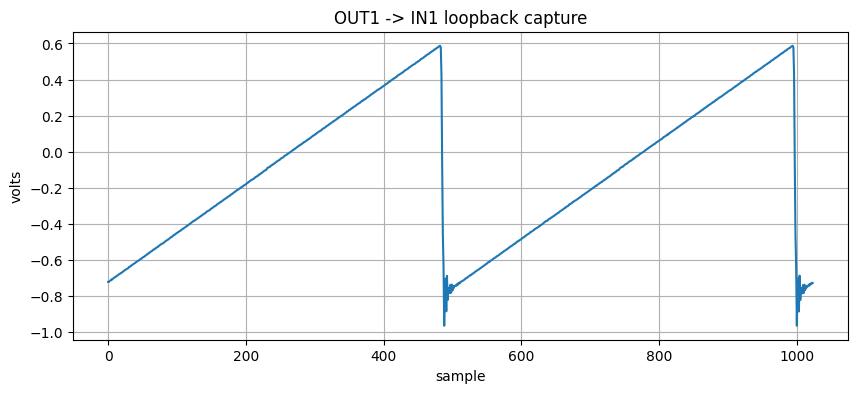

In [10]:
def parse_scpi_ascii_array(text: str) -> np.ndarray:
    """Parse Red Pitaya ASCII array responses like '{0.1,0.2,...}'."""
    cleaned = text.strip().strip("{}").replace(" ", "")
    if not cleaned:
        return np.array([], dtype=np.float64)
    return np.array([float(x) for x in cleaned.split(",") if x], dtype=np.float64)

def wait_for_trigger(timeout_s: float = 3.0) -> str:
    """Poll acquisition trigger state until triggered or timeout."""
    deadline = time.time() + timeout_s
    last = ""
    while time.time() < deadline:
        last = query("ACQ:TRig:STAT?", check=False)
        if last.upper().startswith("TD"):
            return last
        time.sleep(0.05)
    return last

def acquire_input1_latest(samples: int = 1024) -> np.ndarray:
    """Acquire the newest voltage samples from input channel 1.

    This helper does not configure the generator. That matters for the later
    BNET test, where output 1 should come from BNET hardware rather than a
    freshly configured ASG sine wave.
    """
    clear_errors()
    cmd("ACQ:RST")

    # Acquisition setup: return voltage samples as readable ASCII for now.
    cmd("ACQ:DATA:Units VOLTS")
    cmd("ACQ:DATA:FORMAT ASCII")
    cmd("ACQ:DEC 1")
    cmd("ACQ:AVG ON")
    cmd("ACQ:TRig:DLY 0")
    cmd("ACQ:TRig:LEV 0")

    cmd("ACQ:START")
    time.sleep(0.1)
    cmd("ACQ:TRig NOW")
    trig_state = wait_for_trigger()
    print("Trigger state:", trig_state)

    # Get the newest samples from input channel 1.
    rp.tx_txt(f"ACQ:SOUR1:DATA:LATest:N? {samples}")
    data_text = rp.rx_txt()
    rp.check_error(stop=False)
    data = parse_scpi_ascii_array(data_text)

    cmd("ACQ:STOP")
    return data

def asg_to_acq_loopback(freq_hz: float = 10_000, amplitude_v: float = 0.2, samples: int = 1024) -> np.ndarray:
    """Generate a sine on OUT1 and acquire it from IN1.

    This is not a BNET test yet. It is the analog I/O checkout that confirms
    the generator, acquisition, and OUT1-to-IN1 cable are all working.
    """
    clear_errors()
    cmd("GEN:RST")

    # Generator setup: produce a safe sine wave on output channel 1.
    cmd("SOUR1:FUNC SINE")
    cmd(f"SOUR1:FREQ:FIX {freq_hz}")
    cmd(f"SOUR1:VOLT {amplitude_v}")
    cmd("SOUR1:VOLT:OFFS 0")
    cmd("OUTPUT1:STATE ON")

    data = acquire_input1_latest(samples=samples)
    cmd("OUTPUT1:STATE OFF")
    return data

# Uncomment when OUT1 is physically connected to IN1.
captured = asg_to_acq_loopback()
plt.figure(figsize=(10, 4))
plt.plot(captured)
plt.title("OUT1 -> IN1 loopback capture")
plt.xlabel("sample")
plt.ylabel("volts")
plt.grid(True)
plt.show()

## RF OUT1 to IN1 Full-Network Capture

This block runs the full staged BNET DDR test, enables RF output 1, and captures the BNET playback from RF `OUT1` through RF `IN1`.

Hardware setup:

- Load the FPGA bitstream where `butterfly_dat[0]` drives DAC A / RF `OUT1`.
- Physically connect RF `OUT1` to RF `IN1` with a coax cable.
- Keep the input range/gain appropriate for the output amplitude used in the DDR test.

The capture is an analog loopback, so it is not expected to be bit-exact against the PC reference. It should show the same ramp-like result shape from the full staged network.


>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> OUTPUT1:STATE ON
>> SYST:ERR:NEXT?
<< 0,"No error"
>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:START?
<< 16777216
>> BNET:DDR:SIZE?
<< 33554432
OS-reserved DDR region: start=0x01000000, size=33554432 bytes
Slot 0 address: 0x01000000
Slot 1 address: 0x01001000
Payload sizes: stream0=2048 bytes, stream1=20480 bytes
Expected final vector range: -2459..2450 i14 counts
>> BNET:RST

BNET state immediately after RST
>> BNET:STATUS?
<< 0
>> BNET:ACTIVE?
<< 0
>> BNET:PENDING?
<< 0
>> BNET:ERROR?
<< 0
>> BNET:STREAM0:STATUS?
<< 0
>> BNET:STREAM1:STATUS?
<< 0
>> BNET:STREAM0:RPTR?
<< 0
>> BNET:STREAM1:RPTR?
<< 0
>> BNET:STREAM0:DBG0?
<< 524352
>> BNET:STREAM0:DBG1?
<< 0
>> BNET:STREAM1:DBG0?
<< 524352
>> BNET:STREAM1:DBG1?
<< 0
  status          = 0x0
  active          = 0x0
  pending         = 0x0
  error           = 0x0
  stream0_status  = 0x0
  stream1_status  = 0x0
  stream0_rptr    = 0
  stream1_rptr    = 0
  stream0_dbg0    = 0x80040
  

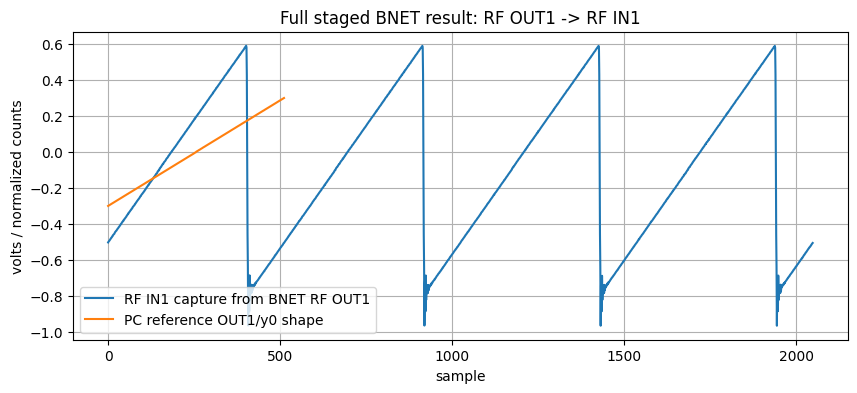

In [11]:
def bnet_rf_out1_in1_capture_test(samples: int = 2048) -> tuple[np.ndarray, np.ndarray]:
    """Run the full staged BNET DDR flow, output on RF OUT1, and acquire RF IN1."""
    clear_errors()

    # Enable the RF OUT1 analog output path before starting the network. The FPGA
    # drives BNET playback into DAC A; OUTPUT1:STATE gates that DAC to the SMA.
    strict_cmd("OUTPUT1:STATE ON")

    # Program DDR, start the full staged engine, and wait until playback is valid.
    # OUT1/DAC A carries y0 playback, which is the even-index half of the final vector.
    result = bnet_ddr_slot_smoke_test()
    expected_out1 = result["expected"][0::2]

    # Confirm the hardware is either actively presenting playback or has completed
    # the run and left the playback loop available on DAC A/RF OUT1.
    status = query_int("BNET:STATUS?")
    assert status & 0x2, "BNET did not report done before RF capture"
    print(f"BNET status before RF capture: 0x{status:x}")

    # Let the analog output settle for a short moment before forcing acquisition.
    time.sleep(0.05)

    # Acquire RF IN1. This helper configures acquisition only; it does not program
    # the generator, so the waveform source remains the BNET DAC playback path.
    captured = acquire_input1_latest(samples=samples)
    print(f"Captured {len(captured)} RF IN1 samples from BNET RF OUT1 playback")

    return captured, expected_out1


def rf_normalize(values: np.ndarray) -> np.ndarray:
    """Return a zero-mean, unit-RMS waveform for analog shape comparison."""
    centered = np.asarray(values, dtype=np.float64) - np.mean(values)
    rms = np.sqrt(np.mean(centered * centered))
    if rms < 1e-12:
        return centered
    return centered / rms


def compare_rf_capture_to_pc_reference(
    captured: np.ndarray,
    expected_i14: np.ndarray,
) -> dict[str, float]:
    """Compare RF IN1 capture against the PC-side OUT1/y0 network reference."""
    reference_volts = expected_i14.astype(np.float64) / ((1 << 13) - 1)
    ref = rf_normalize(reference_volts)
    cap = rf_normalize(captured)
    window = len(ref)
    assert len(cap) >= window, "Capture must contain at least one OUT1/y0 playback period"

    best = {"correlation": -np.inf, "rmse": np.inf, "offset": 0.0}
    for offset in range(0, len(cap) - window + 1):
        segment = cap[offset:offset + window]
        corr = float(np.mean(segment * ref))
        rmse = float(np.sqrt(np.mean((segment - ref) ** 2)))
        if corr > best["correlation"]:
            best = {"correlation": corr, "rmse": rmse, "offset": float(offset)}
    return best


# Run when RF OUT1 is physically connected to RF IN1 and the full BNET bitstream is loaded.
captured_bnet, expected_bnet = bnet_rf_out1_in1_capture_test()
rf_compare = compare_rf_capture_to_pc_reference(captured_bnet, expected_bnet)
print(
    "RF OUT1 vs PC reference: "
    f"corr={rf_compare['correlation']:.3f}, "
    f"rmse={rf_compare['rmse']:.3f}, "
    f"offset={int(rf_compare['offset'])}"
)
assert rf_compare["correlation"] >= 0.90, "RF OUT1 capture does not match PC reference shape"

plt.figure(figsize=(10, 4))
plt.plot(captured_bnet, label="RF IN1 capture from BNET RF OUT1")
plt.plot(expected_bnet / ((1 << 13) - 1), label="PC reference OUT1/y0 shape")
plt.title("Full staged BNET result: RF OUT1 -> RF IN1")
plt.xlabel("sample")
plt.ylabel("volts / normalized counts")
plt.legend()
plt.grid(True)
plt.show()


## Maximum-Length Input DDR Test

This test explicitly exercises the largest input vector supported by the current staged hardware build:

- `2048` input samples on stream 0
- `22528` packed stage-weight words on stream 1
- `4096` sample bytes and `45056` weight bytes consumed from DDR

It reuses the full DDR smoke-test flow, then asserts the returned buffers and PC reference are all maximum length.


In [12]:
def bnet_maximum_length_input_test() -> dict[str, np.ndarray]:
    """Run the full staged DDR test at the maximum hardware vector length."""
    result = bnet_ddr_slot_smoke_test(vector_len=BNET_VECTOR_LEN)

    input_samples = result["input_samples"]
    weights = result["weights"]
    expected = result["expected"]

    assert len(input_samples) == BNET_VECTOR_LEN, "Input payload did not use the maximum vector length"
    assert len(weights) == BNET_TOTAL_WEIGHTS, "Weight payload did not include every staged weight word"
    assert len(expected) == BNET_VECTOR_LEN, "Reference output vector length mismatch"

    print("Maximum-length payload verified")
    print(f"  input samples: {len(input_samples)} words / {len(input_samples) * 2} bytes")
    print(f"  weight words:   {len(weights)} words / {len(weights) * 2} bytes")
    print(f"  output words:   {len(expected)} words")
    return result

max_len_result = bnet_maximum_length_input_test()


>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:START?
<< 16777216
>> BNET:DDR:SIZE?
<< 33554432
OS-reserved DDR region: start=0x01000000, size=33554432 bytes
Slot 0 address: 0x01000000
Slot 1 address: 0x01001000
Payload sizes: stream0=2048 bytes, stream1=20480 bytes
Expected final vector range: -2459..2450 i14 counts
>> BNET:RST

BNET state immediately after RST
>> BNET:STATUS?
<< 0
>> BNET:ACTIVE?
<< 0
>> BNET:PENDING?
<< 0
>> BNET:ERROR?
<< 0
>> BNET:STREAM0:STATUS?
<< 0
>> BNET:STREAM1:STATUS?
<< 0
>> BNET:STREAM0:RPTR?
<< 0
>> BNET:STREAM1:RPTR?
<< 0
>> BNET:STREAM0:DBG0?
<< 524352
>> BNET:STREAM0:DBG1?
<< 0
>> BNET:STREAM1:DBG0?
<< 524352
>> BNET:STREAM1:DBG1?
<< 0
  status          = 0x0
  active          = 0x0
  pending         = 0x0
  error           = 0x0
  stream0_status  = 0x0
  stream1_status  = 0x0
  stream0_rptr    = 0
  stream1_rptr    = 0
  stream0_dbg0    = 0x80040
  stream0_dbg1    = 0x0
  stream1_dbg0    = 0x80040
  stream1_dbg1    = 0x0
>> BNET:DDR:SLOT0:RESE

## Full-Network Output Speed Test

This test measures the staged network run time from `BNET:START` until the BNET status register reports `done`.

The timing intentionally excludes SCPI DDR upload time. The setup phase reserves DDR, uploads the maximum-length sample/weight payload, commits stream buffers, and leaves the hardware ready. The timed phase only covers:

```text
BNET:START -> DDR reader consumption -> staged butterfly compute -> playback-valid/done status
```

Because polling is done over SCPI, the measured time is a coarse upper bound. It is still useful for comparing firmware/bitstream changes across runs.


In [13]:
def prepare_bnet_full_network_run(
    vector_len: int = BNET_VECTOR_LEN,
    input_samples: np.ndarray | None = None,
) -> dict[str, np.ndarray]:
    """Prepare max-length DDR descriptors and payloads, but do not start BNET yet."""
    clear_errors()
    assert vector_len == BNET_VECTOR_LEN, "Current FPGA build is fixed at VECTOR_LEN=2048"

    stage_count = int(np.log2(vector_len))
    input_bytes = vector_len * 2
    weight_bytes = vector_len * stage_count * 2
    slot0_size_bytes = align_up(input_bytes, 0x80)
    slot1_size_bytes = align_up(weight_bytes, 0x80)

    ddr_start = query_int("BNET:DDR:START?")
    ddr_size = query_int("BNET:DDR:SIZE?")
    slot0_addr = spaced_slot_address(ddr_start, 0, slot0_size_bytes)
    slot1_addr = spaced_slot_address(ddr_start, 1, slot0_size_bytes)
    assert slot1_addr + slot1_size_bytes <= ddr_start + ddr_size, "Not enough reserved DDR for speed test slots"

    if input_samples is None:
        input_float = np.linspace(-0.35, 0.35, vector_len, dtype=np.float64)
        input_samples = quantize_sample_i14(input_float)
    else:
        input_samples = np.asarray(input_samples, dtype="<i2")
        assert len(input_samples) == vector_len, "Custom BNET input must match VECTOR_LEN"

    weights = make_identity_stage_weights(vector_len)
    expected = butterfly_reference_i14(input_samples, weights)

    cmd("BNET:RST")
    reserve_bnet_slot(0, slot0_addr, slot0_size_bytes)
    reserve_bnet_slot(1, slot1_addr, slot1_size_bytes)
    upload_bnet_slot_bytes(0, 0, pack_i16_le(input_samples))
    upload_bnet_slot_bytes(1, 0, pack_i16_le(weights))
    attach_slot_to_stream(0, stream=0, buffer=0)
    attach_slot_to_stream(1, stream=1, buffer=0)

    strict_cmd(f"BNET:VLEN {vector_len}")
    strict_cmd("BNET:STREAM0:FORMAT 0")
    strict_cmd("BNET:STREAM1:FORMAT 0")
    strict_cmd("BNET:STREAM0:ENABLE 1")
    strict_cmd("BNET:STREAM1:ENABLE 1")
    strict_cmd("BNET:STREAM0:COMMIT0")
    strict_cmd("BNET:STREAM1:COMMIT0")
    strict_cmd("BNET:MODE DDR")

    pending_before = query_int("BNET:PENDING?")
    error_before = query_int("BNET:ERROR?")
    assert pending_before & 0x3 == 0x3, "Both stream buffers should be pending before the speed run"
    assert error_before == 0, "BNET reported an error before the speed run"

    return {
        "input_samples": input_samples,
        "weights": weights,
        "expected": expected,
        "input_bytes": input_bytes,
        "weight_bytes": weight_bytes,
    }


def bnet_network_output_speed_test(timeout_s: float = 2.0, poll_interval_s: float = 0.001) -> dict[str, float]:
    """Measure start-to-done time for the maximum-length staged BNET run."""
    payload = prepare_bnet_full_network_run()

    t_start = time.perf_counter()
    strict_cmd("BNET:START")

    last_status = 0
    poll_count = 0
    deadline = t_start + timeout_s
    while time.perf_counter() < deadline:
        last_status = query_int("BNET:STATUS?")
        poll_count += 1
        if last_status & 0x2:
            break
        time.sleep(poll_interval_s)
    else:
        bnet_diagnostic_snapshot("BNET state at speed-test timeout")
        raise TimeoutError(f"BNET speed test timed out; last status=0x{last_status:x}")

    t_done = time.perf_counter()
    elapsed_s = t_done - t_start

    error_after = query_int("BNET:ERROR?")
    rptr0_after = query_int("BNET:STREAM0:RPTR?")
    rptr1_after = query_int("BNET:STREAM1:RPTR?")
    hw_time_total = query_int("BNET:TIME0?")
    hw_time_load = query_int("BNET:TIME1?")
    hw_time_compute = query_int("BNET:TIME2?")
    hw_time_playback = query_int("BNET:TIME3?")
    assert error_after == 0, "BNET reported a stream error during speed test"
    assert rptr0_after >= payload["input_bytes"], "Sample stream did not fully drain during speed test"
    assert rptr1_after >= payload["weight_bytes"], "Weight stream did not fully drain during speed test"

    vector_rate = BNET_VECTOR_LEN / elapsed_s
    pair_rate = (BNET_VECTOR_LEN / 2) / elapsed_s
    weight_word_rate = BNET_TOTAL_WEIGHTS / elapsed_s

    print(f"BNET start-to-done time: {elapsed_s * 1e3:.3f} ms")
    print(f"Hardware cycles: total={hw_time_total}, load={hw_time_load}, compute={hw_time_compute}, playback={hw_time_playback}")
    print(f"Status at done: 0x{last_status:x}; SCPI polls: {poll_count}")
    print(f"Effective output vector rate: {vector_rate:.1f} samples/s")
    print(f"Effective butterfly pair rate: {pair_rate:.1f} pairs/s")
    print(f"Effective weight consumption rate: {weight_word_rate:.1f} words/s")

    return {
        "elapsed_s": elapsed_s,
        "vector_samples_per_s": vector_rate,
        "butterfly_pairs_per_s": pair_rate,
        "weight_words_per_s": weight_word_rate,
        "poll_count": float(poll_count),
        "status": float(last_status),
        "hw_cycles_total": float(hw_time_total),
        "hw_cycles_load": float(hw_time_load),
        "hw_cycles_compute": float(hw_time_compute),
        "hw_cycles_playback": float(hw_time_playback),
    }

speed_result = bnet_network_output_speed_test()


>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:START?
<< 16777216
>> BNET:DDR:SIZE?
<< 33554432
>> BNET:RST
>> BNET:DDR:SLOT0:RESERVE 16777216,2048
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:SLOT1:RESERVE 16781312,20480
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:SLOT0:OFFSET0:DATA1024 205,244,211,244,216,244,222,244,228,244,233,244,239,244,244,244,250,244,0,245,5,245,11,245,16,245,22,245,28,245,33,245,39,245,44,245,50,245,56,245,61,245,67,245,72,245,78,245,84,245,89,245,95,245,100,245,106,245,112,245,117,245,123,245,129,245,134,245,140,245,145,245,151,245,157,245,162,245,168,245,173,245,179,245,185,245,190,245,196,245,201,245,207,245,213,245,218,245,224,245,229,245,235,245,241,245,246,245,252,245,1,246,7,246,13,246,18,246,24,246,29,246,35,246,41,246,46,246,52,246,57,246,63,246,69,246,74,246,80,246,85,246,91,246,97,246,102,246,108,246,114,246,119,246,125,246,130,246,136,246,142,246,147,246,153,246,158,246,164,246,170,246,175,246,181,246,186,246,192,246,198,246,203,246,209,2

## Multiple-Input Output Validation and Stability Test

This test runs several distinct maximum-length input vectors through the full staged BNET hardware path. For each trial it uploads a fresh DDR input payload, starts the network, acquires RF OUT1 through RF IN1, and compares the captured waveform against the PC-side fixed-point reference.

The comparison uses sliding normalized correlation because acquisition may not start at output sample zero. The final repeated ramp trial checks run-to-run stability against the first ramp capture.


In [14]:
def normalize_waveform(values: np.ndarray) -> np.ndarray:
    """Return a zero-mean, unit-RMS copy for waveform-shape comparisons."""
    centered = np.asarray(values, dtype=np.float64) - np.mean(values)
    rms = np.sqrt(np.mean(centered * centered))
    if rms < 1e-12:
        return centered
    return centered / rms


def best_sliding_correlation(captured: np.ndarray, expected: np.ndarray) -> dict[str, float]:
    """Find the best normalized correlation of expected inside a captured RF buffer."""
    ref = normalize_waveform(expected)
    cap = normalize_waveform(captured)
    window = len(ref)
    assert len(cap) >= window, "Capture buffer must be at least one output vector long"

    best = {"correlation": -np.inf, "rmse": np.inf, "offset": 0.0}
    for offset in range(0, len(cap) - window + 1):
        segment = cap[offset:offset + window]
        corr = float(np.mean(segment * ref))
        rmse = float(np.sqrt(np.mean((segment - ref) ** 2)))
        if corr > best["correlation"]:
            best = {"correlation": corr, "rmse": rmse, "offset": float(offset)}
    return best


def make_bnet_multi_input_vectors(vector_len: int = BNET_VECTOR_LEN) -> list[tuple[str, np.ndarray]]:
    """Build distinct full-length input vectors for repeated BNET validation."""
    x = np.arange(vector_len, dtype=np.float64)
    ramp = quantize_sample_i14(np.linspace(-0.30, 0.30, vector_len, dtype=np.float64))
    sine = quantize_sample_i14(0.28 * np.sin(2 * np.pi * 7 * x / vector_len))
    triangle_float = 0.26 * (2 * np.abs(2 * (x / vector_len - np.floor(x / vector_len + 0.5))) - 1)
    triangle = quantize_sample_i14(triangle_float)
    cosine_mix = quantize_sample_i14(
        0.18 * np.cos(2 * np.pi * 3 * x / vector_len)
        + 0.10 * np.sin(2 * np.pi * 11 * x / vector_len)
    )
    return [
        ("ramp", ramp),
        ("sine", sine),
        ("triangle", triangle),
        ("cosine_mix", cosine_mix),
        ("ramp_repeat", ramp.copy()),
    ]


def bnet_multiple_input_stability_test(
    capture_samples: int = 2048,
    min_correlation: float = 0.90,
    max_repeat_rmse_delta: float = 0.20,
) -> list[dict[str, float | str]]:
    """Run multiple full-network inputs and validate RF output shape and repeat stability."""
    out1_len = BNET_VECTOR_LEN // 2
    assert capture_samples >= out1_len, "Capture must include at least one full OUT1/y0 playback vector"
    strict_cmd("OUTPUT1:STATE ON")

    trial_results: list[dict[str, float | str]] = []
    first_ramp_segment = None

    for name, input_samples in make_bnet_multi_input_vectors():
        payload = prepare_bnet_full_network_run(input_samples=input_samples)
        strict_cmd("BNET:START")
        status = wait_for_bnet_done()
        assert status & 0x2, f"BNET did not finish trial {name}"

        error_after = query_int("BNET:ERROR?")
        rptr0_after = query_int("BNET:STREAM0:RPTR?")
        rptr1_after = query_int("BNET:STREAM1:RPTR?")
        assert error_after == 0, f"BNET stream error after trial {name}"
        assert rptr0_after >= payload["input_bytes"], f"Sample stream did not drain for trial {name}"
        assert rptr1_after >= payload["weight_bytes"], f"Weight stream did not drain for trial {name}"

        # Let playback settle, then capture RF OUT1 through the OUT1-to-IN1 loopback cable.
        time.sleep(0.05)
        captured = acquire_input1_latest(samples=capture_samples)
        expected_volts = payload["expected"][0::2].astype(np.float64) / ((1 << 13) - 1)
        metrics = best_sliding_correlation(captured, expected_volts)
        assert metrics["correlation"] >= min_correlation, (
            f"Trial {name} correlation {metrics['correlation']:.3f} is below {min_correlation:.3f}"
        )

        repeat_delta = np.nan
        if name == "ramp":
            first_offset = int(metrics["offset"])
            first_ramp_segment = normalize_waveform(captured[first_offset:first_offset + out1_len])
        elif name == "ramp_repeat" and first_ramp_segment is not None:
            repeat_offset = int(metrics["offset"])
            repeat_segment = normalize_waveform(captured[repeat_offset:repeat_offset + out1_len])
            repeat_delta = float(np.sqrt(np.mean((repeat_segment - first_ramp_segment) ** 2)))
            assert repeat_delta <= max_repeat_rmse_delta, (
                f"Repeated ramp changed too much: normalized RMSE delta {repeat_delta:.3f}"
            )

        row = {
            "trial": name,
            "correlation": float(metrics["correlation"]),
            "rmse": float(metrics["rmse"]),
            "offset": float(metrics["offset"]),
            "repeat_rmse_delta": float(repeat_delta),
            "status": float(status),
        }
        trial_results.append(row)
        print(
            f"{name:12s} corr={row['correlation']:.3f} "
            f"rmse={row['rmse']:.3f} offset={int(row['offset'])} "
            f"repeat_delta={row['repeat_rmse_delta']:.3f}"
        )

    print("Multiple-input RF validation and repeat-stability checks passed")
    return trial_results

multi_input_stability_result = bnet_multiple_input_stability_test()


>> OUTPUT1:STATE ON
>> SYST:ERR:NEXT?
<< 0,"No error"
>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:START?
<< 16777216
>> BNET:DDR:SIZE?
<< 33554432
>> BNET:RST
>> BNET:DDR:SLOT0:RESERVE 16777216,2048
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:SLOT1:RESERVE 16781312,20480
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:DDR:SLOT0:OFFSET0:DATA1024 103,246,108,246,112,246,117,246,122,246,127,246,132,246,136,246,141,246,146,246,151,246,156,246,160,246,165,246,170,246,175,246,180,246,184,246,189,246,194,246,199,246,204,246,208,246,213,246,218,246,223,246,228,246,232,246,237,246,242,246,247,246,252,246,0,247,5,247,10,247,15,247,20,247,24,247,29,247,34,247,39,247,44,247,48,247,53,247,58,247,63,247,68,247,72,247,77,247,82,247,87,247,92,247,97,247,101,247,106,247,111,247,116,247,121,247,125,247,130,247,135,247,140,247,145,247,149,247,154,247,159,247,164,247,169,247,173,247,178,247,183,247,188,247,193,247,197,247,202,247,207,247,212,247,217,247,221,247,226,247,231,247,236,247,241,247,245,24

## Cleanup

Run this at the end of a session to leave the generator output off and close the socket cleanly.

In [15]:
def cleanup():
    """Turn off output 1, stop acquisition, and close the SCPI socket."""
    try:
        cmd("OUTPUT1:STATE OFF", check=False)
        cmd("ACQ:STOP", check=False)
    finally:
        rp.close()

# cleanup()